In [1]:
!git clone https://github.com/sht037-lgtm/Q-Vtree.git

Cloning into 'Q-Vtree'...
remote: Enumerating objects: 321, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 321 (delta 64), reused 71 (delta 32), pack-reused 217 (from 1)
Receiving objects: 100% (321/321), 25.55 MiB | 46.98 MiB/s, done.
Resolving deltas: 100% (172/172), done.


In [ ]:
# log in HuggingFace
!pip install -U huggingface_hub
!hf auth login --token "enter your hf token here."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 10.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 46.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.2.0
    Uninstalling hf-xet-1.2.0:
      Successfully uninstalled hf-xet-1.2.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: read).
The token `ZoomEye` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `ZoomEye`


In [3]:
# download Qwen2.5-VL-3B-Instruct Model
%cd Q-Vtree/models
!python download.py
!ls

/kaggle/working/Q-Vtree/models
[INFO] Downloading Qwen/Qwen2.5-VL-3B-Instruct ...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 14 files: 100%|████████████████████████| 14/14 [00:18<00:00,  1.30s/it]
Download complete: : 7.52GB [00:18, 1.26GB/s]                                   [INFO] Download complete: /kaggle/working/Q-Vtree/models/Qwen2.5-VL-3B-Instruct
Model path: /kaggle/working/Q-Vtree/models/Qwen2.5-VL-3B-Instruct
Download complete: : 7.52GB [00:18, 412MB/s] 
download.py  Qwen2.5-VL-3B-Instruct


In [4]:
%cd /kaggle/working/Q-Vtree

# load Qwen model
from transformers import AutoProcessor
import torch
from qwen import Qwen2_5_VLForConditionalGenerationWithTree

model_path = "models/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_path)

model = Qwen2_5_VLForConditionalGenerationWithTree.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()
print("load successfully")

/kaggle/working/Q-Vtree


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

load successfully


In [5]:
!pip install qwen-vl-utils[decord]==0.0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 36.2 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 64.1 MB/s eta 0:00:00:00:0100:01


In [6]:
!ls img

demo_1.jpg	     demo_3_heatmap.png  demo_4_selected.png
demo_2_heatmap.png   demo_3.jpeg	 demo_5_heatmap.png
demo_2.jpeg	     demo_4_heatmap.png  demo_5.jpeg
demo_2_selected.png  demo_4.jpeg	 demo_5_selected.png


In [7]:
demo_img = "img/demo_4.jpeg"

In [8]:
# format input
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "What breed is the dog in the image?"}
        ],
    }
]

text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

from qwen_vl_utils import process_vision_info
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

device = next(model.parameters()).device
inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

In [9]:
# generation
with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=64)

decoded = processor.batch_decode(
    outputs[:, inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("Output:", decoded)

stop
stop
stop
stop
stop
Output: ['\n']


In [10]:
# check tree
selected_nodes = model.model._debug_selected_idx

print("Selected nodes per image:")
for i, nodes in enumerate(selected_nodes):
    print(f"Image {i}: {len(nodes)} nodes")

patch_ids = model.model._debug_patch_ids

print("Selected patches:", len(patch_ids[0]))
print("Total patches:", inputs["pixel_values"].size(0)//4)

Selected nodes per image:
Image 0: 148 nodes
Selected patches: 188
Total patches: 1225


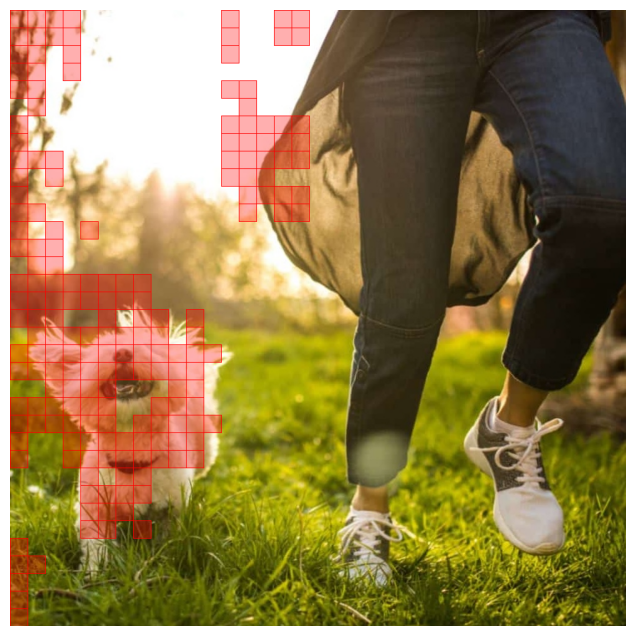

In [11]:
# visualize selected regions
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# selected patches
patch_ids = model.model._debug_patch_ids[0]

# grid size from image_grid_thw
grid_h = inputs["image_grid_thw"][0][1].item()//2
grid_w = inputs["image_grid_thw"][0][2].item()//2

patch_size = 28
image_size = grid_h * patch_size

# load image
img = Image.open(demo_img).convert("RGB").resize((image_size, image_size))

overlay = Image.new("RGBA", img.size, (0,0,0,0))
draw = ImageDraw.Draw(overlay)

for idx in patch_ids:

    r = idx // grid_w
    c = idx % grid_w

    x0 = int(c * patch_size)
    y0 = int(r * patch_size)
    x1 = int((c + 1) * patch_size)
    y1 = int((r + 1) * patch_size)

    draw.rectangle(
        [x0, y0, x1, y1],
        fill=(255,0,0,80),
        outline=(255,0,0,255)
    )

out = Image.alpha_composite(img.convert("RGBA"), overlay)

plt.figure(figsize=(8,8))
plt.imshow(out)
plt.axis("off")

# plt.savefig(f"{demo_img}_selected.png", dpi=300)
plt.show()

/tmp/ipykernel_55/2445357989.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scores = torch.tensor(scores).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]


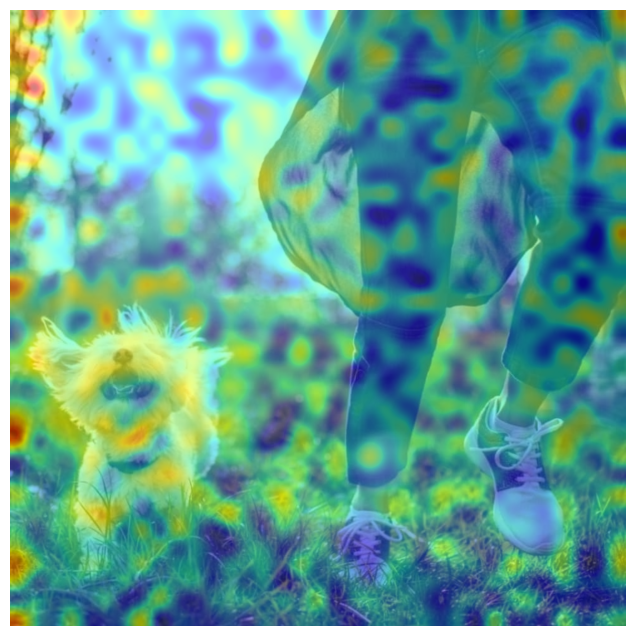

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch.nn.functional as F
import torch

# patch scores
scores = model.model.qvtree._debug_patch_scores[0].detach().cpu()

# reshape to grid
grid = int(scores.shape[0] ** 0.5)
scores = scores.reshape(grid, grid)

# normalize
scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-6)

# --- smooth interpolation ---
scores = torch.tensor(scores).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
scores = F.interpolate(
    scores,
    size=(1120,1120),
    mode="bicubic",
    align_corners=False
)
scores = scores.squeeze().numpy()

# load image
img = Image.open(demo_img).convert("RGB").resize((1120,1120))

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.imshow(scores, cmap="jet", alpha=0.5)
plt.axis("off")

# plt.savefig(f"{demo_img}_heatmap.png", dpi=300)
plt.show()